<a href="https://colab.research.google.com/github/gunchugh/Error-Analysis/blob/main/Error%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/diamonds.csv')
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [ ]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [ ]:
df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


In [ ]:
df.duplicated().sum()

np.int64(146)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.select_dtypes(include='object').columns

Index(['cut', 'color', 'clarity'], dtype='object')

In [ ]:
df=pd.get_dummies(df,drop_first=True)

In [ ]:
numeric_df=df.select_dtypes(include=['int64','float64'])

<Axes: >

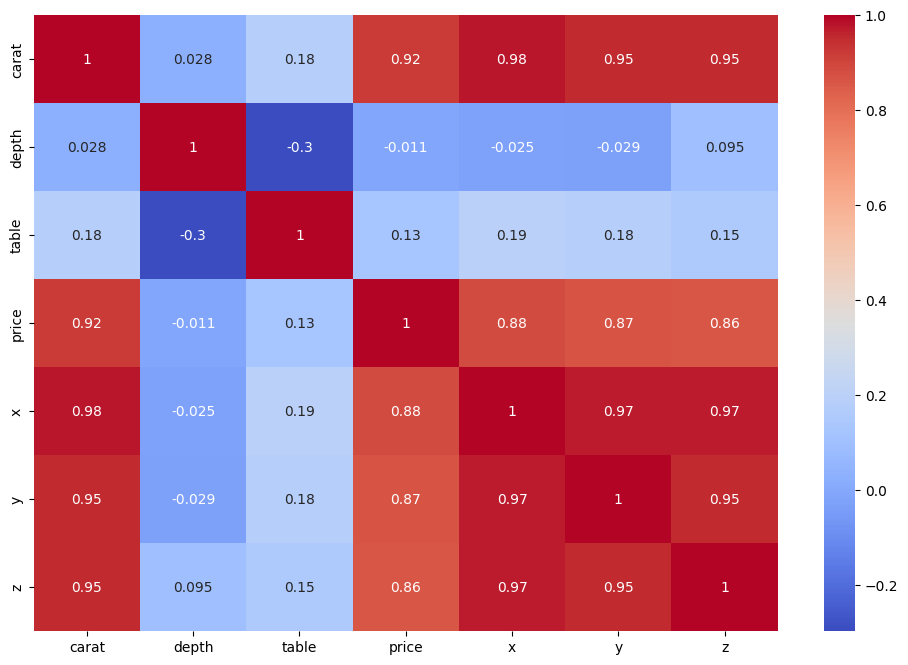

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(),cmap='coolwarm',annot=True)

In [ ]:
x=df.drop('price',axis=1)
y=df['price']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
model.coef_

array([ 1.12681080e+04, -6.09824786e+01, -2.66084036e+01, -9.75978041e+02,
        3.54307503e+00, -1.02100392e+02,  5.76999535e+02,  8.24419552e+02,
        7.57103115e+02,  7.25209141e+02, -2.09336920e+02, -2.74473948e+02,
       -4.80335282e+02, -9.71723821e+02, -1.45979635e+03, -2.37716803e+03,
        5.40604106e+03,  3.69185313e+03,  2.71383045e+03,  4.60304742e+03,
        4.28827046e+03,  5.01952692e+03,  4.95612304e+03])

In [ ]:
train_pred=model.predict(x_train)
train_pred[:5]

array([ 1208.71642519, 16512.55881994,  2309.83502862,  4015.00547532,
        2062.44317111])

In [ ]:
y_train.head().values

array([  829, 16558,  1721,  3312,  1444])

In [ ]:
test_pred = model.predict(x_test)
test_pred[:5]

array([ 700.07217051, 3754.66272195, 2630.13669808, 1938.28088804,
       6185.4579702 ])

In [ ]:
y_test.head().values

array([1435, 3584, 1851, 1590, 5690])

In [ ]:

from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error

In [ ]:
print('Train Mean Squared Error :',mean_squared_error(y_train,train_pred))
print('Train Root Mean Squared Error :',np.sqrt(mean_squared_error(y_train,train_pred)))
print('Train Mean Absolute Error :',mean_absolute_error(y_train,train_pred))
print('Train Mean Absolute Percentage Error :',mean_absolute_percentage_error(y_train,train_pred))
print('Train R2 Score :-',r2_score(y_train,train_pred))

Train Mean Squared Error : 1288639.284668654
Train Root Mean Squared Error : 1135.1824895886361
Train Mean Absolute Error : 742.8698772773054
Train Mean Absolute Percentage Error : 0.39126253249575654
Train R2 Score :- 0.9198095725639233


In [ ]:
print('Test Mean Squared Error :',mean_absolute_error(y_test,test_pred))
print('Test Root Mean Squared Error :',np.sqrt(mean_squared_error(y_test,test_pred)))
print('Test Mean Absolute Error :',mean_absolute_error(y_test,test_pred))
print('Test Mean Absolute Percentage Error :',mean_absolute_percentage_error(y_test,test_pred))
print('Test R2 Score :-',r2_score(y_test,test_pred))

Test Mean Squared Error : 725.2703212681351
Test Root Mean Squared Error : 1102.3129790728701
Test Mean Absolute Error : 725.2703212681351
Test Mean Absolute Percentage Error : 0.3794176575635993
Test R2 Score :- 0.9202802581013377
